In [6]:
import sys
sys.path.append('..')
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('../data/processed/clean.csv')
print(df.shape)
df.head()

(300030, 28)


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,...,route,is_ecoomy,airline_enc,source_city_enc,destination_city_enc,route_enc,departure_time_enc,arrival_time_enc,stops_enc,class_enc
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,...,Delhi_Mumbai,1,4,2,5,14,2,5,2,1
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,...,Delhi_Mumbai,1,4,2,5,14,1,4,2,1
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,...,Delhi_Mumbai,1,0,2,5,14,1,1,2,1
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,...,Delhi_Mumbai,1,5,2,5,14,4,0,2,1
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,...,Delhi_Mumbai,1,5,2,5,14,4,4,2,1


In [10]:
print(df.columns)

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'is_last_minute', 'is_advance_booking', 'book_window',
       'duration_total_mins', 'stops_num', 'dep_time_num', 'arr_time_num',
       'route', 'is_ecoomy', 'airline_enc', 'source_city_enc',
       'destination_city_enc', 'route_enc', 'departure_time_enc',
       'arrival_time_enc', 'stops_enc', 'class_enc'],
      dtype='str')


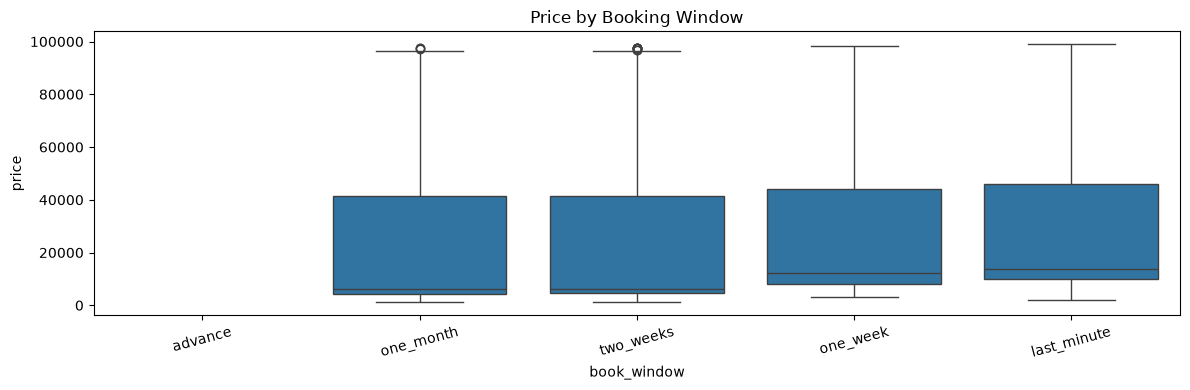

In [11]:
# Cell 2 — Most important relationship: days_left vs price
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='book_window', y='price',
            order=['advance','one_month','two_weeks','one_week','last_minute'])
plt.title('Price by Booking Window')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

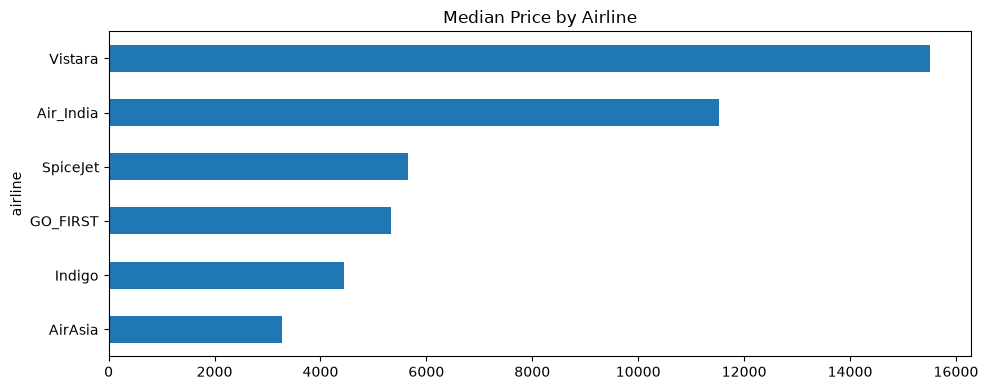

In [12]:
# Cell 3 — Price by airline
plt.figure(figsize=(10, 4))
df.groupby('airline')['price'].median().sort_values().plot(kind='barh')
plt.title('Median Price by Airline')
plt.tight_layout()
plt.show()

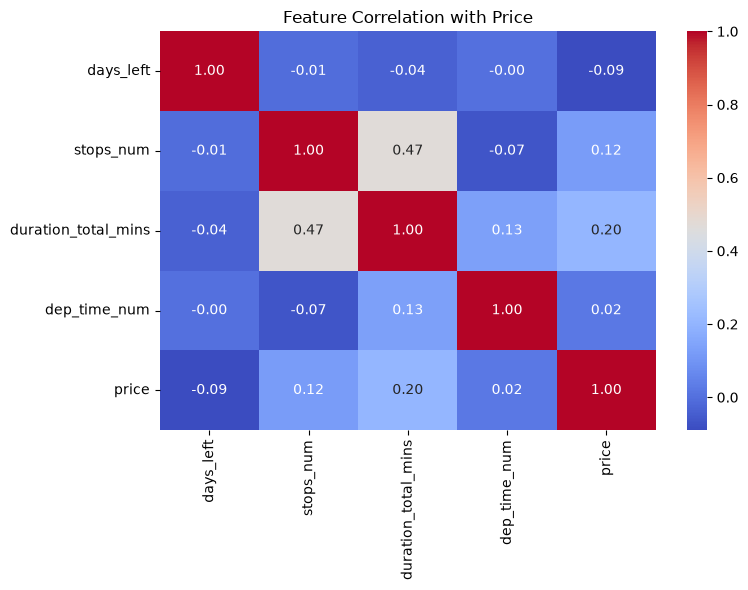

In [13]:
# Cell 4 — Correlation heatmap (your feature health check)
import numpy as np
num_cols = ['days_left', 'stops_num', 'duration_total_mins',
            'dep_time_num', 'is_economy', 'price']
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation with Price')
plt.tight_layout()
plt.show()

In [14]:
# Cell 5 — Top 10 routes by volume (tells you which routes to model)
top_routes = df['route'].value_counts().head(10)
print("Top 10 routes by ticket count:")
print(top_routes)

Top 10 routes by ticket count:
route
Delhi_Mumbai        15289
Mumbai_Delhi        14808
Delhi_Bangalore     14012
Bangalore_Delhi     13755
Bangalore_Mumbai    12935
Mumbai_Bangalore    12867
Mumbai_Kolkata      12601
Delhi_Kolkata       11917
Kolkata_Mumbai      11458
Delhi_Chennai       10772
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
import sys

sys.path.append('..')
from src.preprocess import get_feature_matrix

x,y=get_feature_matrix(df)

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)

import numpy as np
np.save('../data/processed/X_train.npy', x_train)
np.save('../data/processed/X_test.npy', x_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy', y_test)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (240024, 11), Test: (60006, 11)
